In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the 500,000-record featured dataset
DATA_PATH = "../data/processed/chicago_crime_featured.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset shape: {df.shape}")

Dataset shape: (500000, 36)


## EDA 1: Top Crime Types


Number of crime types: 31

Crime Distribution:
                                    Count  Percentage
Primary Type                                         
THEFT                              116381       23.28
BATTERY                             90191       18.04
CRIMINAL DAMAGE                     54950       10.99
ASSAULT                             45413        9.08
MOTOR VEHICLE THEFT                 38513        7.70
OTHER OFFENSE                       33979        6.80
DECEPTIVE PRACTICE                  30387        6.08
BURGLARY                            21005        4.20
NARCOTICS                           13822        2.76
ROBBERY                             13663        2.73
WEAPONS VIOLATION                   12516        2.50
CRIMINAL TRESPASS                   10791        2.16
CRIMINAL SEXUAL ASSAULT              3367        0.67
OFFENSE INVOLVING CHILDREN           3223        0.64
SEX OFFENSE                          2639        0.53
PUBLIC PEACE VIOLATION             

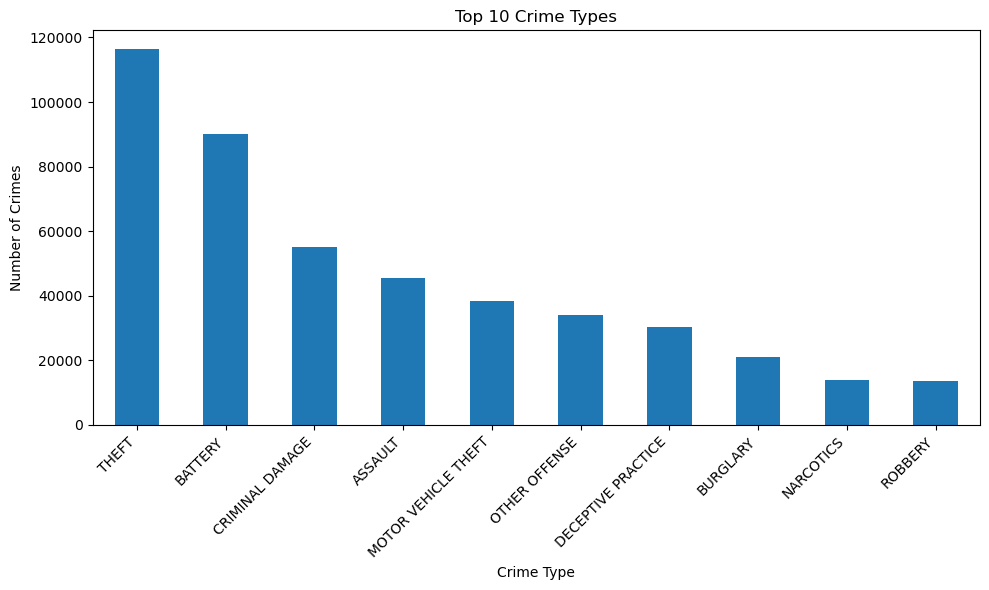

In [2]:
# Crime distribution across all crime types
crime_counts = df["Primary Type"].value_counts()
crime_percentages = (
    df["Primary Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

crime_distribution = pd.DataFrame({
    "Count": crime_counts,
    "Percentage": crime_percentages
})

print("Number of crime types:", df["Primary Type"].nunique())
print("\nCrime Distribution:")
print(crime_distribution)

# Visualize Top 10 crime types for readability
top_10_crimes = crime_counts.head(10)

plt.figure(figsize=(10, 6))
top_10_crimes.plot(kind="bar")

plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "../outputs/plots/top_10_crime_types.png",
    bbox_inches="tight"
)

plt.show()

## EDA 2: Crimes by Hour


Peak crime hour: 0:00
Number of crimes during peak hour: 33,784


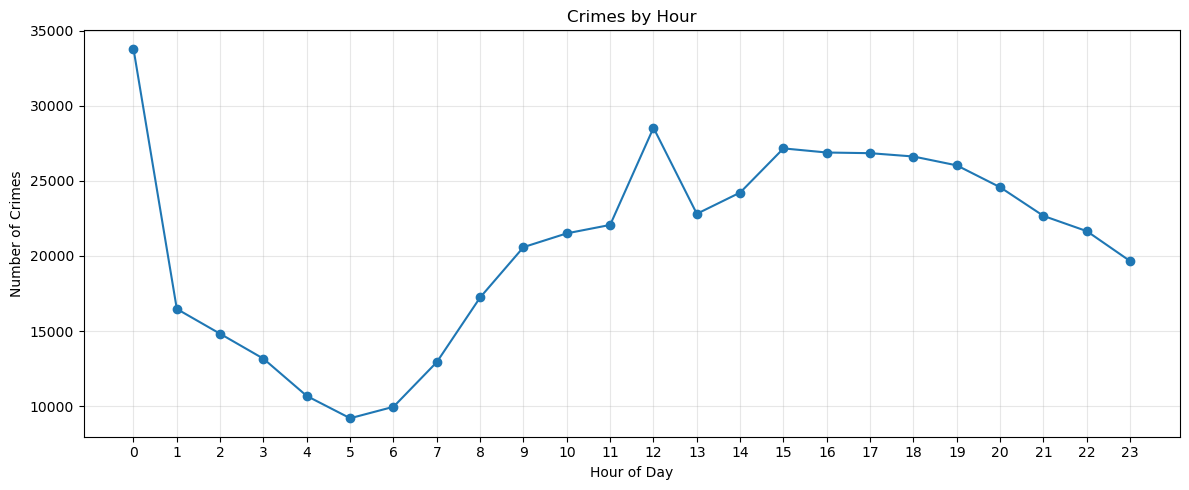

In [3]:
# Analyze hourly crime distribution
hourly_crime = df["Hour"].value_counts().sort_index()

# Identify peak crime hour
peak_hour = hourly_crime.idxmax()
peak_count = hourly_crime.max()

print(f"Peak crime hour: {peak_hour}:00")
print(f"Number of crimes during peak hour: {peak_count:,}")

# Plot hourly crime trend
plt.figure(figsize=(12, 5))
hourly_crime.plot(kind="line", marker="o")

plt.title("Crimes by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/plots/crimes_by_hour.png",
    bbox_inches="tight"
)

plt.show()

## EDA 3: Crimes by Day


Highest crime day: Friday
Number of crimes: 74,135


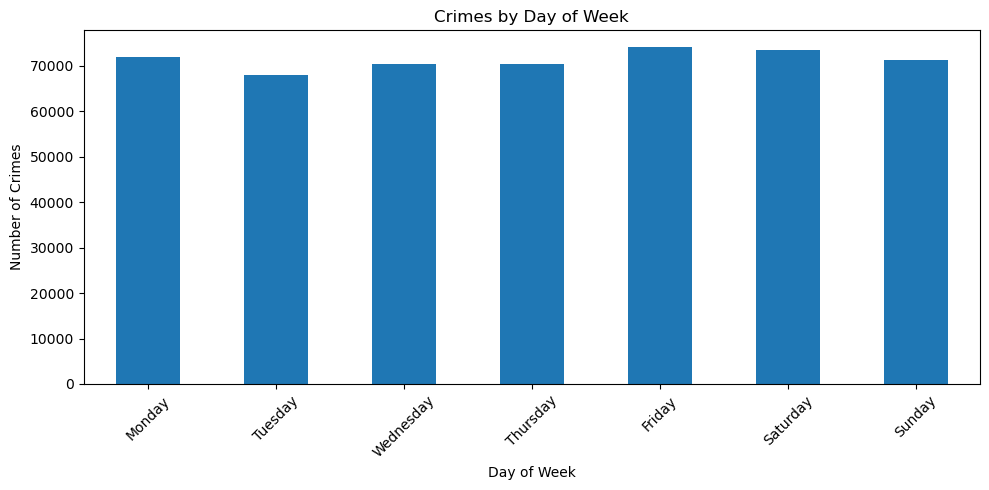

In [4]:
# Analyze crime distribution by day of week
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_counts = (
    df["Day_of_Week"]
    .value_counts()
    .reindex(day_order)
)

# Identify the day with the highest crime count
peak_day = day_counts.idxmax()
peak_day_count = day_counts.max()

print(f"Highest crime day: {peak_day}")
print(f"Number of crimes: {peak_day_count:,}")

# Plot daily crime pattern
plt.figure(figsize=(10, 5))
day_counts.plot(kind="bar")

plt.title("Crimes by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/plots/crimes_by_day.png",
    bbox_inches="tight"
)

plt.show()

## EDA 4: Arrest Analysis


In [5]:
# Analyze arrest rate
arrest_rate = (
    df["Arrest"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Arrest Rate Distribution:")
print(arrest_rate)

# Overall percentage of crimes resulting in arrest
overall_arrest_rate = df["Arrest"].mean() * 100

print(f"\nOverall Arrest Rate: {overall_arrest_rate:.2f}%")
print(f"No Arrest Rate: {100 - overall_arrest_rate:.2f}%")

Arrest Rate Distribution:
Arrest
False    84.95
True     15.05
Name: proportion, dtype: float64

Overall Arrest Rate: 15.05%
No Arrest Rate: 84.95%


## EDA 5: Domestic Crime Analysis


In [6]:
# Analyze domestic incident rate
domestic_rate = (
    df["Domestic"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Domestic Incident Distribution:")
print(domestic_rate)

# Overall percentage of domestic incidents
overall_domestic_rate = df["Domestic"].mean() * 100

print(f"\nDomestic Incident Rate: {overall_domestic_rate:.2f}%")
print(f"Non-Domestic Incident Rate: {100 - overall_domestic_rate:.2f}%")

Domestic Incident Distribution:
Domestic
False    81.16
True     18.84
Name: proportion, dtype: float64

Domestic Incident Rate: 18.84%
Non-Domestic Incident Rate: 81.16%


## EDA 6: Crime Heatmap Preparation


In [7]:
# Geographic coordinate statistical summary
geo_summary = df[["Latitude", "Longitude"]].describe()

print("Geographic Coordinate Summary:")
print(geo_summary)

Geographic Coordinate Summary:
            Latitude      Longitude
count  500000.000000  500000.000000
mean       41.846586     -87.667988
std         0.086241       0.058924
min        41.644590     -87.934567
25%        41.772532     -87.708967
50%        41.864628     -87.660613
75%        41.909363     -87.626751
max        42.022559     -87.524529


## EDA 7: Monthly Crime Analysis


Highest crime month: May
Number of crimes: 58,779


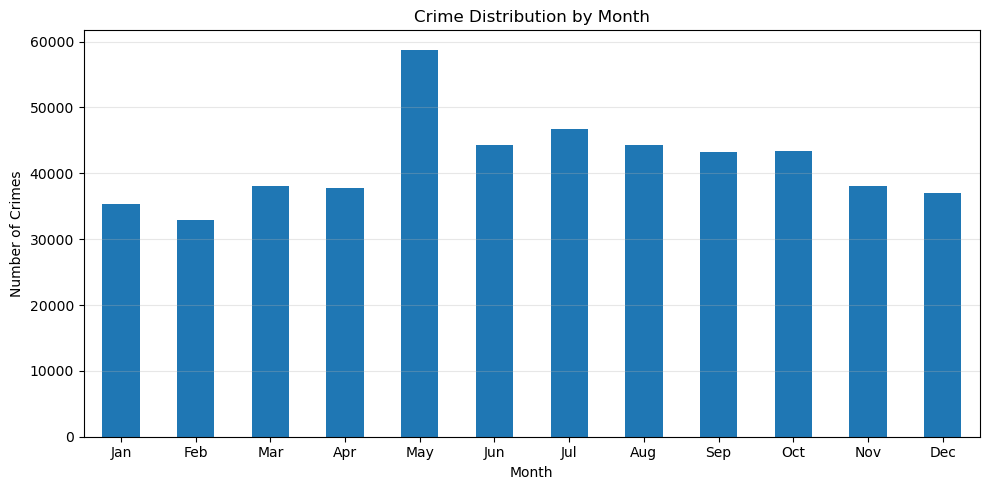

In [8]:
# Analyze monthly crime distribution
monthly_crime = df["Month"].value_counts().sort_index()

# Identify month with the highest crime count
peak_month = monthly_crime.idxmax()
peak_month_count = monthly_crime.max()

month_names = {
    1: "January", 2: "February", 3: "March",
    4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September",
    10: "October", 11: "November", 12: "December"
}

print(f"Highest crime month: {month_names[peak_month]}")
print(f"Number of crimes: {peak_month_count:,}")

# Plot monthly crime pattern
plt.figure(figsize=(10, 5))
monthly_crime.plot(kind="bar")

plt.title("Crime Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(
    range(12),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=0
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/plots/crimes_by_month.png",
    bbox_inches="tight"
)

plt.show()

## EDA 8: Seasonal Crime Analysis


Highest crime season: Summer
Number of crimes: 135,197


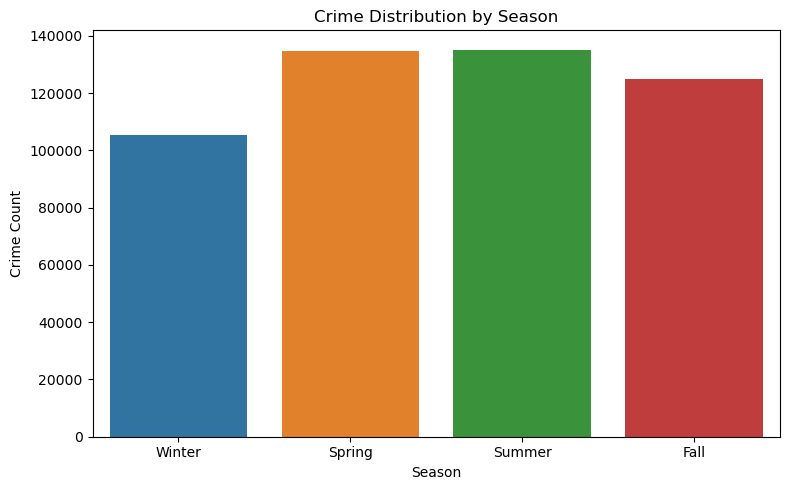

In [9]:
# Analyze seasonal crime distribution
season_order = ["Winter", "Spring", "Summer", "Fall"]

season_counts = (
    df["Season"]
    .value_counts()
    .reindex(season_order)
)

# Identify season with the highest crime count
peak_season = season_counts.idxmax()
peak_season_count = season_counts.max()

print(f"Highest crime season: {peak_season}")
print(f"Number of crimes: {peak_season_count:,}")

# Plot seasonal crime distribution
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values,
    hue=season_counts.index,
    legend=False
)

plt.title("Crime Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Crime Count")
plt.tight_layout()

plt.savefig(
    "../outputs/plots/crimes_by_season.png",
    bbox_inches="tight"
)

plt.show()

## EDA 9: Geographic Crime Distribution


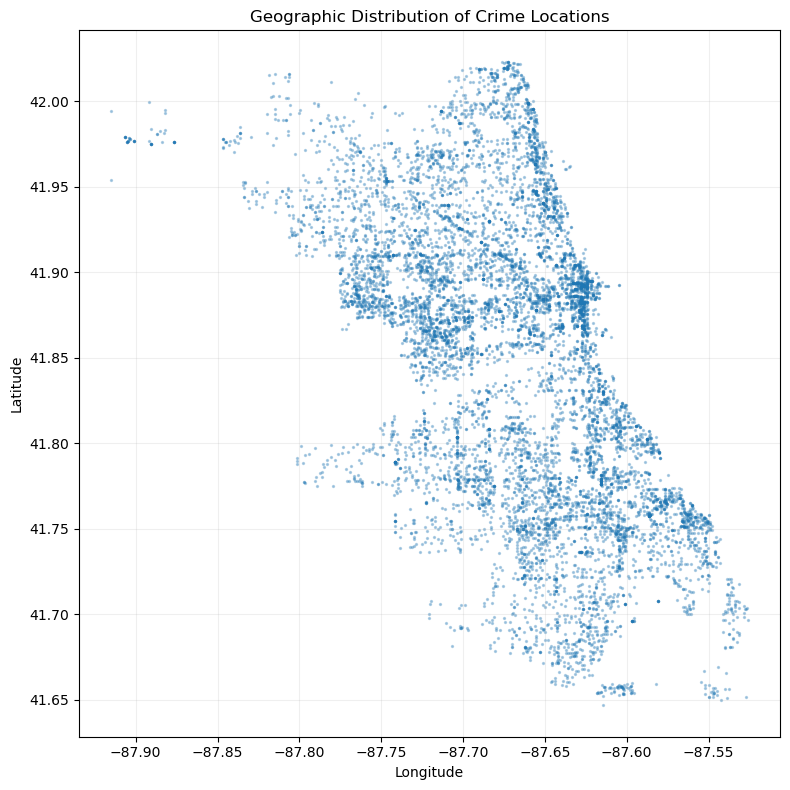

In [10]:
# Analyze geographic crime distribution using a sample
sample = df.sample(10000, random_state=42)

plt.figure(figsize=(8, 8))

plt.scatter(
    sample["Longitude"],
    sample["Latitude"],
    s=2,
    alpha=0.3
)

plt.title("Geographic Distribution of Crime Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../outputs/plots/geographic_crime_distribution.png",
    bbox_inches="tight"
)

plt.show()

## EDA 10: Arrest vs Domestic


Domestic vs Arrest Counts:
Arrest     False  True 
Domestic               
False     345372  60449
True       79357  14822

Domestic vs Arrest Percentage:
Arrest    False  True 
Domestic              
False     85.10  14.90
True      84.26  15.74


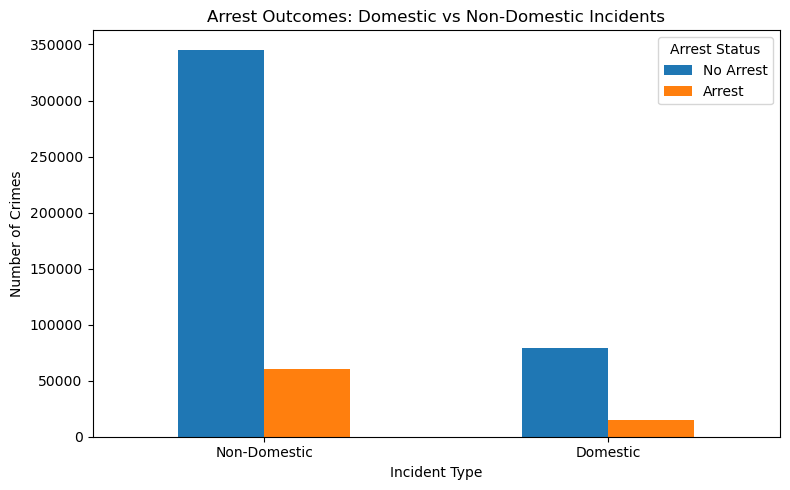

In [11]:
# Analyze relationship between Domestic incidents and Arrests

# Count-based cross-tabulation
cross = pd.crosstab(
    df["Domestic"],
    df["Arrest"]
)

print("Domestic vs Arrest Counts:")
print(cross)

# Arrest rate within domestic and non-domestic incidents
arrest_by_domestic = (
    pd.crosstab(
        df["Domestic"],
        df["Arrest"],
        normalize="index"
    ) * 100
).round(2)

print("\nDomestic vs Arrest Percentage:")
print(arrest_by_domestic)

# Plot count comparison
cross.index = ["Non-Domestic", "Domestic"]
cross.columns = ["No Arrest", "Arrest"]

cross.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Arrest Outcomes: Domestic vs Non-Domestic Incidents")
plt.xlabel("Incident Type")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=0)
plt.legend(title="Arrest Status")
plt.tight_layout()

plt.savefig(
    "../outputs/plots/domestic_vs_arrest.png",
    bbox_inches="tight"
)

plt.show()

## EDA 11: Statistical Summary


In [12]:
# Comprehensive statistical summary

print("DATASET INFORMATION")
print("=" * 50)
df.info()

print("\nSTATISTICAL SUMMARY")
print("=" * 50)

summary = df.describe(include="all")
print(summary)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ID                            500000 non-null  int64  
 1   Case Number                   500000 non-null  object 
 2   Date                          500000 non-null  object 
 3   Block                         500000 non-null  object 
 4   IUCR                          500000 non-null  object 
 5   Primary Type                  500000 non-null  object 
 6   Description                   500000 non-null  object 
 7   Location Description          500000 non-null  object 
 8   Arrest                        500000 non-null  bool   
 9   Domestic                      500000 non-null  bool   
 10  Beat                          500000 non-null  int64  
 11  District                      500000 non-null  int64  
 12  Ward                    

## EDA 12: Key Crime Insights


In [13]:
# EDA 12: Key Crime Insights

top_crime = df["Primary Type"].value_counts()
hourly_counts = df["Hour"].value_counts()
daily_counts = df["Day_of_Week"].value_counts()
monthly_counts = df["Month"].value_counts()
seasonal_counts = df["Season"].value_counts()

month_names = {
    1: "January", 2: "February", 3: "March",
    4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September",
    10: "October", 11: "November", 12: "December"
}

arrest_rate = df["Arrest"].mean() * 100
domestic_rate = df["Domestic"].mean() * 100

domestic_arrest_rates = (
    df.groupby("Domestic")["Arrest"]
    .mean()
    .mul(100)
)

print("KEY CRIME INSIGHTS")
print("=" * 60)

print(f"1. Crime types represented: {df['Primary Type'].nunique()}")

print(
    f"2. Most common crime: {top_crime.idxmax()} "
    f"({top_crime.max():,} incidents, "
    f"{top_crime.max() / len(df) * 100:.2f}%)"
)

print(
    f"3. Peak recorded hour: {hourly_counts.idxmax()}:00 "
    f"({hourly_counts.max():,} incidents)"
)

print(
    f"4. Highest recorded day: {daily_counts.idxmax()} "
    f"({daily_counts.max():,} incidents)"
)

print(
    f"5. Highest recorded month: "
    f"{month_names[monthly_counts.idxmax()]} "
    f"({monthly_counts.max():,} incidents)"
)

print(
    f"6. Highest recorded season: {seasonal_counts.idxmax()} "
    f"({seasonal_counts.max():,} incidents)"
)

print(f"7. Overall arrest rate: {arrest_rate:.2f}%")
print(f"8. Domestic incident rate: {domestic_rate:.2f}%")

print(
    f"9. Arrest rate for non-domestic incidents: "
    f"{domestic_arrest_rates[False]:.2f}%"
)

print(
    f"10. Arrest rate for domestic incidents: "
    f"{domestic_arrest_rates[True]:.2f}%"
)

KEY CRIME INSIGHTS
1. Crime types represented: 31
2. Most common crime: THEFT (116,381 incidents, 23.28%)
3. Peak recorded hour: 0:00 (33,784 incidents)
4. Highest recorded day: Friday (74,135 incidents)
5. Highest recorded month: May (58,779 incidents)
6. Highest recorded season: Summer (135,197 incidents)
7. Overall arrest rate: 15.05%
8. Domestic incident rate: 18.84%
9. Arrest rate for non-domestic incidents: 14.90%
10. Arrest rate for domestic incidents: 15.74%


## EDA 13: Domestic Status and Arrest Association


In [14]:
# ============================================================
# EDA VALIDATION: DOMESTIC vs ARREST ASSOCIATION
# ============================================================

import numpy as np
from scipy.stats import chi2_contingency

# ------------------------------------------------------------
# 1. Contingency table
# ------------------------------------------------------------

contingency_table = pd.crosstab(
    df["Domestic"],
    df["Arrest"]
)

print("=" * 65)
print("DOMESTIC STATUS vs ARREST STATUS")
print("=" * 65)

print("\nContingency Table:")
print(contingency_table)


# ------------------------------------------------------------
# 2. Chi-Square Test of Independence
# ------------------------------------------------------------

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("\nCHI-SQUARE TEST")
print(f"Chi-square statistic : {chi2:.4f}")
print(f"P-value              : {p_value:.6g}")
print(f"Degrees of freedom   : {dof}")


# ------------------------------------------------------------
# 3. Cramér's V
# ------------------------------------------------------------

n = contingency_table.to_numpy().sum()
rows, cols = contingency_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(rows - 1, cols - 1))
)

print("\nASSOCIATION STRENGTH")
print(f"Cramér's V: {cramers_v:.4f}")


# ------------------------------------------------------------
# 4. Arrest-rate comparison
# ------------------------------------------------------------

arrest_rates = (
    df.groupby("Domestic")["Arrest"]
    .mean()
    .mul(100)
)

non_domestic_arrest = arrest_rates.loc[False]
domestic_arrest = arrest_rates.loc[True]

difference = domestic_arrest - non_domestic_arrest

print("\nARREST RATE COMPARISON")
print(f"Non-Domestic Arrest Rate : {non_domestic_arrest:.2f}%")
print(f"Domestic Arrest Rate     : {domestic_arrest:.2f}%")
print(f"Difference               : {difference:.2f} percentage points")


# ------------------------------------------------------------
# 5. Interpretation
# ------------------------------------------------------------

print("\nINTERPRETATION")

if p_value < 0.05:
    print(
        "Domestic status and arrest status show a "
        "statistically significant association."
    )
else:
    print(
        "No statistically significant association was "
        "detected between domestic status and arrest status."
    )

if cramers_v < 0.10:
    strength = "very weak"
elif cramers_v < 0.30:
    strength = "weak"
elif cramers_v < 0.50:
    strength = "moderate"
else:
    strength = "strong"

print(
    f"The strength of association is {strength} "
    f"(Cramér's V = {cramers_v:.4f})."
)

print("\nNote: Statistical association does not establish causation.")

DOMESTIC STATUS vs ARREST STATUS

Contingency Table:
Arrest     False  True 
Domestic               
False     345372  60449
True       79357  14822

CHI-SQUARE TEST
Chi-square statistic : 42.3761
P-value              : 7.5306e-11
Degrees of freedom   : 1

ASSOCIATION STRENGTH
Cramér's V: 0.0092

ARREST RATE COMPARISON
Non-Domestic Arrest Rate : 14.90%
Domestic Arrest Rate     : 15.74%
Difference               : 0.84 percentage points

INTERPRETATION
Domestic status and arrest status show a statistically significant association.
The strength of association is very weak (Cramér's V = 0.0092).

Note: Statistical association does not establish causation.
